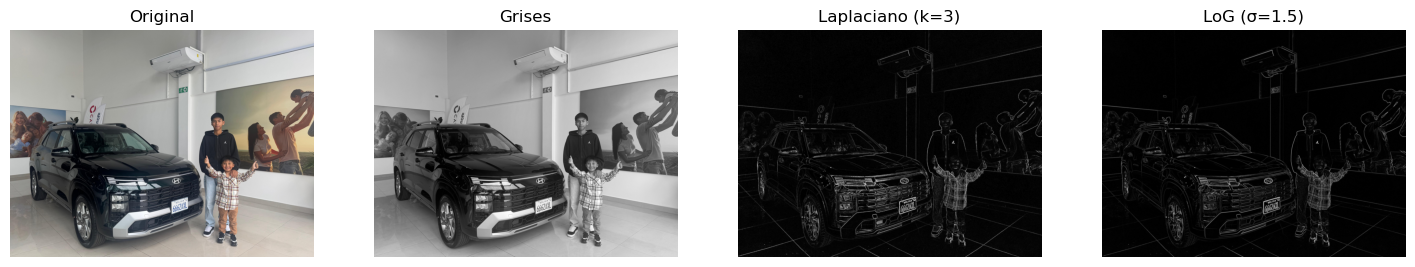

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace

imagen_bgr  = cv2.imread('img.jpeg')
imagen_rgb  = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
imagen_gray = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)

KSIZE = 3
SIGMA = 1.5

laplaciano    = cv2.Laplacian(imagen_gray, cv2.CV_64F, ksize=KSIZE)
lap_abs       = cv2.convertScaleAbs(laplaciano)

log_scipy     = gaussian_laplace(imagen_gray.astype(np.float64), sigma=SIGMA)
log_scipy_abs = np.uint8(np.clip(np.abs(log_scipy) * 10, 0, 255))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img, titulo in zip(axes,
    [imagen_rgb, imagen_gray, lap_abs, log_scipy_abs],
    ['Original', 'Grises', f'Laplaciano (k={KSIZE})', f'LoG (σ={SIGMA})']):
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    ax.set_title(titulo)
    ax.axis('off')

plt.show()